# How much does a random split flatter a crop classifier?

**Spatial leakage in parcel-level crop type classification from Sentinel-2 time series**

UTS Machine Learning, Assignment A2 (Option 2).

Crop type classifiers are usually evaluated by splitting parcels into train and
test sets at random. Neighbouring parcels share soil, weather and farming
practice, so a random split lets the model be tested on parcels that closely
resemble ones it trained on. This notebook measures how much that flatters
the reported performance, by comparing random splits against held-out
*regions*, and examines what makes the gap larger or less predictable.

### How to run

| mode | what it does | time |
|---|---|---|
| `quick` (default) | all four regions, ~5% of parcels, 50 boosting rounds | ~20 min download on a fresh machine, then a few minutes |
| `full` | all 608k parcels, 200 rounds: produces the reported numbers | 3-4 hours |

Set `MODE` in the setup cell, or run headless from a terminal:

```
CROP_MODE=full jupyter nbconvert --to notebook --execute --inplace crop_leakage.ipynb --ExecutePreprocessor.timeout=-1
```

The saved outputs in this notebook are from a `full` run. Quick mode exists so
anyone can check the pipeline runs end to end without waiting hours; its
numbers are not the reported ones.

The download cannot be made smaller in quick mode: the research question is
about generalising across *regions*, so every region has to be present.

## 1. Task definition

**Deployment input.** One agricultural parcel, as a Sentinel-2 Level-1C time
series: an array of shape `(T, 13)`, where `T` is the number of satellite
acquisitions over the 2017 growing season and 13 is the number of spectral
bands (B1 to B12 including B8A, in standard order). Each value is
top-of-atmosphere reflectance, averaged over the pixels inside the parcel
boundary. Values lie roughly in [0, 1] and can exceed 1 under cloud. The
exact `T` and value range observed in the data are printed in section 3.

**Deployment output.** One of 7 crop labels:
`barley, wheat, rapeseed, corn, orchards, permanent meadows, temporary meadows`.
Internally the model produces a vector of 7 real-valued margins `z`; the
prediction is `argmax(z)`, and `softmax(z)` can be read as class probabilities.

**Training data.** BreizhCrops (Rußwurm et al., 2020): 608,263 parcels in
Brittany, France, with labels from farmers' 2017 CAP declarations, split by
the dataset authors into four NUTS-3 regions (`frh01`-`frh04`). Sunflower (19
parcels) and nuts (49) are excluded as too rare to evaluate, leaving 608,195
parcels and 7 classes.

**Evaluation.** Leave-one-region-out: train on three regions, test on the
fourth, repeat for all four. Reported as mean +/- standard deviation over
folds, for accuracy and macro F1, with a majority-class baseline.

**The core difficulty.** The model is always deployed on parcels whose
region it may never have seen. Performance measured on a random split
estimates something different: performance on parcels that sit beside
training parcels. How different is the question.

## 2. Setup

In [1]:
import os, sys, subprocess, time, platform
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "breizhcrops", "xgboost"], check=True)

MODE = os.environ.get("CROP_MODE", "quick")      # "quick" or "full"

CONFIGS = {
    "quick": dict(sample_frac=0.05, rounds=50,  gamma_grid=[0.0, 2.0],           select_frac=0.5),
    "full":  dict(sample_frac=1.0,  rounds=200, gamma_grid=[0.0, 1.0, 2.0, 3.0], select_frac=0.3),
}
CFG = CONFIGS[MODE]

SEED = 42
MAX_DEPTH, ETA = 6, 0.1
REGIONS = ["frh01", "frh02", "frh03", "frh04"]
RARE = ["sunflower", "nuts"]
FOCAL_GAMMA_EXP1 = 2.0

DATA_DIR, RESULTS_DIR, FIG_DIR = Path("data"), Path("results"), Path("figures")
for d in (DATA_DIR, RESULTS_DIR, FIG_DIR):
    d.mkdir(exist_ok=True)

T_START = time.time()
PROGRESS_FILE = RESULTS_DIR / "progress.log"


def tick(msg):
    """Append a timestamped line to results/progress.log and echo it.

    nbconvert only writes cell output when the whole notebook finishes, so
    during a long headless run the notebook itself tells you nothing. This
    file is flushed on every call, so a second terminal can follow it live:

        Get-Content results\\progress.log -Wait -Tail 20      (PowerShell)
        tail -f results/progress.log                          (bash)
    """
    line = f"[{time.strftime('%H:%M:%S')}  +{(time.time() - T_START)/60:6.1f} min]  {msg}"
    with open(PROGRESS_FILE, "a", encoding="utf-8") as fh:
        fh.write(line + "\n")
        fh.flush()
    print(line)


PROGRESS_FILE.write_text("", encoding="utf-8")       # fresh log each run
tick(f"start   MODE={MODE}  {CFG}")
print(f"running in {'Colab' if IN_COLAB else 'local environment'}")

[13:54:45  +   0.0 min]  start   MODE=full  {'sample_frac': 1.0, 'rounds': 200, 'gamma_grid': [0.0, 1.0, 2.0, 3.0], 'select_frac': 0.3}
running in local environment


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy import stats
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from importlib.metadata import version

print(f"python {platform.python_version()}")
for pkg in ["numpy", "pandas", "xgboost", "scikit-learn", "scipy", "breizhcrops"]:
    try:
        print(f"{pkg:13s} {version(pkg)}")
    except Exception:
        print(f"{pkg:13s} (version unavailable)")

python 3.12.3
numpy         2.5.3
pandas        3.0.6
xgboost       3.4.1
scikit-learn  1.9.1
scipy         1.18.1
breizhcrops   0.0.4.1


## 3. Features

A tree model needs a fixed-length vector, but each parcel is a `(T, 13)` time
series. How the time axis is collapsed turns out to matter a great deal.

- **basic** (52): per-band mean, std, min, max. *Order-free*: shuffling the
  acquisition dates leaves them unchanged, so the model cannot see phenology.
- **segment** (78): per-band means over 6 consecutive windows. Coarse
  temporal shape.
- **harmonic** (65): per-band order-2 Fourier fit
  $x(t) \approx a_0 + \sum_{k=1}^{2} a_k \cos(2\pi k t/T) + b_k \sin(2\pi k t/T)$.
  Smooth seasonal shape.
- **four index families** (6 each): the same six curve descriptors — peak
  height, peak timing, mean, green-up and senescence slopes, amplitude —
  applied to four spectral indices. (The season integral was dropped: it is
  `sum/T`, a constant multiple of the mean, so it carried no extra
  information.)

| index | formula | tracks |
|---|---|---|
| NDVI | $(B8-B4)/(B8+B4)$ | greenness |
| NDRE | $(B8-B5)/(B8+B5)$ | chlorophyll, via the red edge |
| NDWI | $(B8-B11)/(B8+B11)$ | vegetation water content (Gao) |
| EVI | $2.5(B8-B4)/(B8+6B4-7.5B2+1)$ | canopy structure |

**Why include indices at all, when the raw bands are already there?** XGBoost
splits on one feature at a time, with rules of the form
`band 7 > 0.31`. It cannot form a *ratio* between two features, no matter how
many trees it grows. An index is a nonlinear combination of bands, so it is
genuinely new information rather than a repackaging of what the model already
has.

The four are tested **separately** rather than as one block, so the
experiments can distinguish "NDVI behaves this way" from "index features
behave this way".

Two caveats, stated rather than hidden. EVI was designed for surface
reflectance and this data is top-of-atmosphere, so its blue term is
aerosol-sensitive; its denominator is also clipped because it can approach
zero on bright pixels. And band positions are *assumed* to follow standard
Sentinel-2 order (B2, B4, B5, B8, B11 at indices 1, 3, 4, 7, 11), which is
checked against the data below rather than trusted.

In [3]:
# Sentinel-2 band positions (standard order B1..B12 incl. B8A)
BLUE_IDX, RED_IDX, RE1_IDX, NIR_IDX, SWIR1_IDX = 1, 3, 4, 7, 11   # B2, B4, B5, B8, B11
N_SEGMENTS, EPS = 6, 1e-8

BANDS = [f"b{i}" for i in range(13)]
STATS = ["mean", "std", "min", "max"]
CURVE_STATS = ["peak", "argmax", "mean", "greenup", "senescence", "amplitude"]
INDICES = ["ndvi", "ndre", "ndwi", "evi"]

# Order matches extract_features: all 13 means, then all 13 stds, and so on.
BASIC_NAMES    = [f"{b}_{s}" for s in STATS for b in BANDS]
SEGMENT_NAMES  = [f"{b}_seg{j}" for b in BANDS for j in range(N_SEGMENTS)]
HARMONIC_NAMES = [f"{b}_{h}" for b in BANDS for h in ("h0", "h1c", "h1s", "h2c", "h2s")]
INDEX_NAMES    = {ix: [f"{ix}_{c}" for c in CURVE_STATS] for ix in INDICES}

FEATURE_NAMES = (BASIC_NAMES + SEGMENT_NAMES + HARMONIC_NAMES
                 + [n for ix in INDICES for n in INDEX_NAMES[ix]])
FAMILIES = {"basic": BASIC_NAMES, "segment": SEGMENT_NAMES, "harmonic": HARMONIC_NAMES,
            **{ix: INDEX_NAMES[ix] for ix in INDICES}}

_PINV = {}

def _harmonic_pinv(T):
    """Pseudo-inverse of the Fourier design matrix; identical for every parcel of length T."""
    if T not in _PINV:
        t = np.arange(T) / T
        design = np.stack([np.ones(T),
                           np.cos(2*np.pi*t), np.sin(2*np.pi*t),
                           np.cos(4*np.pi*t), np.sin(4*np.pi*t)], axis=1)   # (T, 5)
        _PINV[T] = np.linalg.pinv(design)                                   # (5, T)
    return _PINV[T]


def curve_descriptors(v, T):
    """Seven shape descriptors of one index series over the season."""
    k = int(v.argmax())
    return np.array([
        v.max(),
        k / max(T - 1, 1),                        # when the peak occurred, 0..1
        v.mean(),
        (v[k] - v[0]) / max(k, 1),                # green-up slope
        (v[-1] - v[k]) / max(T - 1 - k, 1),       # senescence slope
        v.max() - v.min(),
    ])


def extract_features(x):
    """x: (T, 13) reflectance. Returns a vector of len(FEATURE_NAMES)."""
    x = np.asarray(x, dtype=np.float64)
    T = x.shape[0]

    basic = np.concatenate([x.mean(0), x.std(0), x.min(0), x.max(0)])

    edges = np.linspace(0, T, N_SEGMENTS + 1).astype(int)
    segment = np.stack([x[edges[j]:edges[j+1]].mean(0) for j in range(N_SEGMENTS)],
                       axis=1).reshape(-1)                                  # band-major

    harmonic = (_harmonic_pinv(T) @ x).T.reshape(-1)                        # band-major

    blue, red, re1 = x[:, BLUE_IDX], x[:, RED_IDX], x[:, RE1_IDX]
    nir, swir1 = x[:, NIR_IDX], x[:, SWIR1_IDX]

    series = {
        "ndvi": (nir - red) / (nir + red + EPS),              # greenness
        "ndre": (nir - re1) / (nir + re1 + EPS),              # chlorophyll, red edge
        "ndwi": (nir - swir1) / (nir + swir1 + EPS),          # water content (Gao)
        # EVI denominator is clipped: it can approach zero on bright/hazy L1C pixels.
        "evi": np.clip(2.5 * (nir - red)
                       / np.maximum(nir + 6 * red - 7.5 * blue + 1.0, 0.1), -2.0, 2.0),
    }
    index_feats = np.concatenate([curve_descriptors(series[ix], T) for ix in INDICES])
    return np.concatenate([basic, segment, harmonic, index_feats])


print(f"{len(FEATURE_NAMES)} features: " + ", ".join(f"{k}={len(v)}" for k, v in FAMILIES.items()))

219 features: basic=52, segment=78, harmonic=65, ndvi=6, ndre=6, ndwi=6, evi=6


**Verification.** Each check tests a property the feature code is supposed to
have, rather than trusting it.

In [4]:
rng = np.random.default_rng(0)
T = 45
names = np.array(FEATURE_NAMES)

# 1. Names line up with values. Band i holds i + t/T, so for band 5:
#    min = 5, max = 5 + (T-1)/T, mean = 5 + (T-1)/(2T).
x = np.arange(13)[None, :] + (np.arange(T) / T)[:, None]
f = dict(zip(FEATURE_NAMES, extract_features(x)))
assert np.isclose(f["b5_min"], 5.0)
assert np.isclose(f["b5_max"], 5 + (T - 1) / T)
assert np.isclose(f["b5_mean"], 5 + (T - 1) / (2 * T))
assert np.isclose(f["b0_max"], (T - 1) / T)
print("1. feature names match their values")

# 2. Shuffle test: basic must be order-free, every other family order-aware.
x = rng.random((T, 13))
f1, f2 = extract_features(x), extract_features(x[rng.permutation(T)])
for fam, fnames in FAMILIES.items():
    m = np.isin(names, fnames)
    delta = np.abs(f1[m] - f2[m]).max()
    print(f"2. shuffle  {fam:9s} max change {delta:.2e}  "
          f"{'order-free' if delta < 1e-10 else 'order-aware'}")
    assert (delta < 1e-10) == (fam == "basic")

# 3. Harmonic fit recovers a planted seasonal signal exactly.
t = np.arange(T) / T
x = np.tile((0.5 + 0.3*np.cos(2*np.pi*t) - 0.2*np.sin(2*np.pi*t))[:, None], (1, 13))
h = extract_features(x)[np.isin(names, HARMONIC_NAMES)].reshape(13, 5)[0]
assert np.allclose(h, [0.5, 0.3, -0.2, 0, 0], atol=1e-9)
print(f"3. harmonic recovery  {np.round(h, 6)}")

# 4. NDVI phenology on a synthetic season peaking mid-way.
x = np.zeros((T, 13))
x[:, RED_IDX] = 0.4 - 0.25*np.sin(np.pi*np.arange(T)/T)
x[:, NIR_IDX] = 0.2 + 0.5*np.sin(np.pi*np.arange(T)/T)
f = dict(zip(FEATURE_NAMES, extract_features(x)))
assert 0.4 < f["ndvi_argmax"] < 0.6 and f["ndvi_greenup"] > 0 > f["ndvi_senescence"]
print(f"4. synthetic season  ndvi peak={f['ndvi_peak']:.3f} timing={f['ndvi_argmax']:.3f}")

# 5. All four indices are finite and in range on realistic reflectance.
x = np.clip(rng.random((T, 13)) * 0.6, 0.01, None)
f = dict(zip(FEATURE_NAMES, extract_features(x)))
for ix in INDICES:
    vals = [f[n] for n in INDEX_NAMES[ix]]
    assert np.all(np.isfinite(vals)), f"{ix} produced non-finite values"
    assert abs(f[f"{ix}_peak"]) <= 2.0
print("5. ndvi, ndre, ndwi, evi all finite and in range")

1. feature names match their values
2. shuffle  basic     max change 2.22e-16  order-free
2. shuffle  segment   max change 2.97e-01  order-aware
2. shuffle  harmonic  max change 1.74e-01  order-aware
2. shuffle  ndvi      max change 8.64e-01  order-aware
2. shuffle  ndre      max change 1.14e-01  order-aware
2. shuffle  ndwi      max change 8.64e-01  order-aware
2. shuffle  evi       max change 7.50e-02  order-aware
3. harmonic recovery  [ 0.5  0.3 -0.2  0.  -0. ]
4. synthetic season  ndvi peak=0.647 timing=0.500
5. ndvi, ndre, ndwi, evi all finite and in range


## 4. Data

Downloads each region on first use (about 5.7 GB in total, cached afterwards)
and extracts features. In quick mode a random 5% of parcels per region is
sampled *before* extraction, which is what makes it fast.

In [5]:
import breizhcrops as bzh
import pyarrow.parquet as pq

cache = DATA_DIR / f"nb_features_{MODE}.parquet"

def cache_is_current(path):
    """A cache built by an older feature set must not be reused silently."""
    if not path.exists():
        return False
    have = set(pq.ParquetFile(path).schema.names)
    missing = [c for c in FEATURE_NAMES if c not in have]
    if missing:
        print(f"cache {path.name} is stale: missing {len(missing)} columns "
              f"(e.g. {missing[:3]}). Rebuilding.")
        return False
    return True


if cache_is_current(cache):
    df = pd.read_parquet(cache)
    print(f"loaded cached features from {cache}: {df.shape}")
else:
    rng = np.random.default_rng(SEED)
    frames, classnames = [], None
    for region in REGIONS:
        t0 = time.time()
        ds = bzh.BreizhCrops(region)
        cn = list(ds.classname)
        assert classnames is None or cn == classnames, "class list differs between regions"
        classnames = cn

        n = len(ds)
        if CFG["sample_frac"] >= 1:
            idx = np.arange(n)
        else:
            idx = np.sort(rng.choice(n, size=int(round(n * CFG["sample_frac"])), replace=False))

        F = np.empty((len(idx), len(FEATURE_NAMES)), dtype=np.float32)
        lab = np.empty(len(idx), dtype=np.int64)
        fid = np.empty(len(idx), dtype=np.int64)
        tlen = np.empty(len(idx), dtype=np.int64)
        xmin = np.empty(len(idx), dtype=np.float32)
        xmax = np.empty(len(idx), dtype=np.float32)

        for k, i in enumerate(idx):
            x, y, field_id = ds[int(i)]
            x = np.asarray(x, dtype=np.float64)
            F[k] = extract_features(x)
            lab[k], fid[k], tlen[k] = int(y), int(field_id), x.shape[0]
            xmin[k], xmax[k] = x.min(), x.max()

        d = pd.DataFrame(F, columns=FEATURE_NAMES)
        d["label9"], d["field_id"], d["region"] = lab, fid, region
        d["T"], d["x_min"], d["x_max"] = tlen, xmin, xmax
        frames.append(d)
        tick(f"features: {region} done ({len(idx):,} of {n:,} parcels, "
             f"{time.time() - t0:.0f}s)")

    df = pd.concat(frames, ignore_index=True)
    df["classname"] = [classnames[i] for i in df["label9"]]
    df.to_parquet(cache)
    print(f"wrote {cache}: {df.shape}")

n_nonfinite = int((~np.isfinite(df[FEATURE_NAMES].values)).sum())
print(f"non-finite feature values: {n_nonfinite}")
assert n_nonfinite == 0

[14:12:26  +  17.7 min]  features: frh01 done (178,613 of 178,613 parcels, 1055s)


[14:26:51  +  32.1 min]  features: frh02 done (140,645 of 140,645 parcels, 865s)


[14:44:20  +  49.6 min]  features: frh03 done (166,391 of 166,391 parcels, 1049s)


[14:52:32  +  57.8 min]  features: frh04 done (122,614 of 122,614 parcels, 492s)


wrote data\nb_features_full.parquet: (608263, 226)


non-finite feature values: 0


**Grounding the input specification in the data.**

In [6]:
print("sequence length T:")
print(df["T"].value_counts().sort_index().to_string())
print(f"\nreflectance range: 1st pct of parcel minima {np.percentile(df.x_min, 1):.3f}, "
      f"99th pct of parcel maxima {np.percentile(df.x_max, 99):.3f}, "
      f"overall max {df.x_max.max():.3f}")

# Band-order check. If red/NIR are right, vegetated parcels show clearly
# positive NDVI peaking mid-season. Swapped bands give strongly negative
# values; two wrong bands give noise near zero.
peak, timing = df["ndvi_peak"], df["ndvi_argmax"]
print(f"\nNDVI peak    median {peak.median():.3f}  (5th {peak.quantile(.05):.3f}, 95th {peak.quantile(.95):.3f})")
print(f"NDVI timing  median {timing.median():.3f}  (0 = season start, 1 = season end)")
assert peak.median() > 0.2 and 0.1 < timing.median() < 0.9, "band indices look wrong"
print("band order assumption: consistent with vegetation phenology")

sequence length T:
T
45    608263

reflectance range: 1st pct of parcel minima 0.001, 99th pct of parcel maxima 1.449, overall max 2.480

NDVI peak    median 0.650  (5th 0.582, 95th 0.727)
NDVI timing  median 0.523  (0 = season start, 1 = season end)
band order assumption: consistent with vegetation phenology


In [7]:
df = df[~df["classname"].isin(RARE)].reset_index(drop=True)
order = df.drop_duplicates("label9").sort_values("label9")["classname"].tolist()
CLASS_NAMES = order                                  # original order, rare classes removed
K = len(CLASS_NAMES)
label_map = {c: i for i, c in enumerate(CLASS_NAMES)}

y = df["classname"].map(label_map).values
regions = df["region"].values

counts = pd.crosstab(df["classname"], df["region"]).reindex(CLASS_NAMES)
counts["total"] = counts.sum(axis=1)
counts["share"] = (counts["total"] / counts["total"].sum()).round(4)
print(f"{len(df)} parcels, {K} classes")
display(counts)

608195 parcels, 7 classes


region,frh01,frh02,frh03,frh04,total,share
classname,,,,,,
barley,13046,10733,7148,5978,36905,0.0607
wheat,30368,15005,27189,16993,89555,0.1472
rapeseed,5593,2346,3557,3236,14732,0.0242
corn,43990,36593,41992,31333,153908,0.2531
orchards,944,350,1223,553,3070,0.0050
permanent meadows,32650,36512,32534,26117,127813,0.2102
temporary meadows,52011,39082,52728,38391,182212,0.2996


## 5. Loss function: multiclass focal loss as a custom XGBoost objective

XGBoost fits each tree using the gradient and the diagonal Hessian of the loss
with respect to the raw margins `z`. Supplying those two arrays is all a
custom objective needs to do.

Let $p = \mathrm{softmax}(z)$, $t$ the true class, $u = p_t$, and $\alpha_t$ a
per-class weight. Focal loss is

$$L = -\alpha_t (1-u)^\gamma \log u .$$

With $\gamma = 0$ this is class-weighted cross entropy; with $\gamma > 0$ the
factor $(1-u)^\gamma$ shrinks the loss on samples the model already gets
right, focusing training on hard ones.

**Derivatives with respect to $u$:**

$$g(u) = \frac{\partial L}{\partial u} = \alpha_t\left[\gamma(1-u)^{\gamma-1}\log u - \frac{(1-u)^\gamma}{u}\right]$$

$$g'(u) = \alpha_t\left[-\gamma(\gamma-1)(1-u)^{\gamma-2}\log u + \frac{2\gamma(1-u)^{\gamma-1}}{u} + \frac{(1-u)^\gamma}{u^2}\right]$$

**Chain rule through the softmax**, using $\partial u/\partial z_k = u(\delta_{tk} - p_k)$:

$$\frac{\partial L}{\partial z_k} = g(u)\,u\,(\delta_{tk}-p_k)$$

$$\frac{\partial^2 L}{\partial z_k^2} = \big(g'(u)u + g(u)\big)\,u\,(\delta_{tk}-p_k)^2 \;-\; g(u)\,u\,p_k(1-p_k)$$

**Sanity check.** At $\gamma=0$, $\alpha=1$: $g=-1/u$ and $g'u+g=0$, so the
gradient is $p_k-\delta_{tk}$ and the Hessian is $p_k(1-p_k)$, which is
exactly XGBoost's built-in `multi:softmax`.

**Two implementation details.** XGBoost uses only the Hessian's diagonal; the
off-diagonal terms are dropped, as they are in its built-in multiclass
objective. And the Hessian is floored at `1e-6`, because XGBoost divides by
summed Hessians to set leaf values and focal loss can produce near-zero or
slightly negative curvature on very confident correct predictions.

In [8]:
HESS_FLOOR = 1e-6


def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def focal_grad_hess(z, y, gamma=2.0, alpha=None):
    """Gradient and diagonal Hessian of multiclass focal loss wrt margins z (n, K)."""
    z = np.asarray(z, dtype=np.float64)
    y = np.asarray(y, dtype=np.int64)
    n, K = z.shape
    a_t = (np.ones(K) if alpha is None else np.asarray(alpha, dtype=np.float64))[y]

    p = softmax(z)
    onehot = np.zeros_like(p)
    onehot[np.arange(n), y] = 1.0
    u = np.clip(p[np.arange(n), y], EPS, 1 - EPS)
    om, log_u = 1 - u, np.log(u)

    g  = a_t * (gamma * om**(gamma - 1) * log_u - om**gamma / u)
    gp = a_t * (-gamma * (gamma - 1) * om**(gamma - 2) * log_u
                + 2 * gamma * om**(gamma - 1) / u
                + om**gamma / u**2)

    g, gp, u = g[:, None], gp[:, None], u[:, None]
    d = onehot - p                                          # delta_tk - p_k

    grad = g * u * d
    hess = (gp * u + g) * u * d**2 - g * u * p * (1 - p)
    return grad, np.maximum(hess, HESS_FLOOR)


def focal_loss(z, y, gamma=2.0, alpha=None):
    z, y = np.asarray(z, dtype=np.float64), np.asarray(y, dtype=np.int64)
    n, K = z.shape
    a_t = (np.ones(K) if alpha is None else np.asarray(alpha, dtype=np.float64))[y]
    u = np.clip(softmax(z)[np.arange(n), y], EPS, 1 - EPS)
    return float(np.mean(-a_t * (1 - u)**gamma * np.log(u)))


def make_objective(gamma, alpha, K):
    def objective(preds, dtrain):
        y = dtrain.get_label().astype(np.int64)
        z = np.asarray(preds, dtype=np.float64)
        if z.ndim == 1:
            z = z.reshape(y.size, K)
        return focal_grad_hess(z, y, gamma=gamma, alpha=alpha)
    return objective

**Verification.** The analytic derivatives are checked two independent ways:
against central finite differences of the loss, and against the closed-form
reduction at $\gamma=0$. The second is the stronger check: finite differences
say the derivatives are *close*; the identity says the algebra is *right*.

The Hessian agrees with finite differences to about $10^{-5}$ rather than
$10^{-10}$. That is the method's noise floor, not an error: a second-order
difference divides by $h^2$, so rounding error scales like
$\varepsilon/h^2 \approx 10^{-16}/10^{-10} = 10^{-6}$.

In [9]:
def numeric_grad_hess(z, y, gamma, alpha, h=1e-5):
    n = z.shape[0]
    total = lambda zz: focal_loss(zz, y, gamma, alpha) * n      # sum, not mean
    l0 = total(z)
    G, H = np.zeros_like(z), np.zeros_like(z)
    for i in range(z.shape[0]):
        for k in range(z.shape[1]):
            zp, zm = z.copy(), z.copy()
            zp[i, k] += h; zm[i, k] -= h
            lp, lm = total(zp), total(zm)
            G[i, k] = (lp - lm) / (2 * h)
            H[i, k] = (lp - 2 * l0 + lm) / h**2
    return G, H


rng = np.random.default_rng(0)
print(f"{'case':28s}{'max grad err':>14s}{'max hess err':>14s}")
for gamma, alpha, tag in [(0.0, None, "gamma=0"), (1.0, None, "gamma=1"),
                          (2.0, None, "gamma=2"), (2.0, [1, 3, .5, 2], "gamma=2, weighted")]:
    z, yy = rng.normal(0, 1.5, (6, 4)), rng.integers(0, 4, 6)
    ga, ha = focal_grad_hess(z, yy, gamma, alpha)
    gn, hn = numeric_grad_hess(z, yy, gamma, alpha)
    live = ha > HESS_FLOOR * 1.000001
    ge, he = np.abs(ga - gn).max(), np.abs(ha - hn)[live].max()
    print(f"{tag:28s}{ge:14.2e}{he:14.2e}")
    assert ge < 1e-7 and he < 1e-3

z, yy = rng.normal(0, 1, (5, 4)), rng.integers(0, 4, 5)
p = softmax(z); onehot = np.eye(4)[yy]
ga, ha = focal_grad_hess(z, yy, gamma=0.0)
print(f"\ngamma=0 identity:  |grad - (p - onehot)| = {np.abs(ga - (p - onehot)).max():.1e}   "
      f"|hess - p(1-p)| = {np.abs(ha - p*(1-p)).max():.1e}")
assert np.abs(ga - (p - onehot)).max() < 1e-12

case                          max grad err  max hess err
gamma=0                           5.71e-11      2.01e-05
gamma=1                           4.43e-11      1.47e-05
gamma=2                           7.89e-11      2.62e-05
gamma=2, weighted                 1.80e-10      3.86e-05

gamma=0 identity:  |grad - (p - onehot)| = 0.0e+00   |hess - p(1-p)| = 0.0e+00


## 6. Evaluation protocol

- **Leave-one-region-out (LORO).** Each of the four regions is held out in
  turn. Results are mean +/- sd over the four folds.
- **Size-matched random control.** For every regional fold, a random split
  with the *same* train and test sizes is drawn from the same pool.
  Otherwise part of any gap could just be a difference in training set size.
  The *leakage gap* is random accuracy minus regional accuracy.
- **Majority-class baseline** per fold, for context.
- **Class weights** `alpha` (inverse frequency, mean-normalised) are
  computed from the training data of each fold only.
- **Paired tests.** Comparisons between configurations use the same four
  regions, so they are paired. With 4 folds a paired t-test has 3 degrees of
  freedom; p-values are indicative, and the number of folds agreeing in
  direction is reported alongside.

In [10]:
def class_weights(labels):
    c = np.maximum(np.bincount(labels, minlength=K).astype(np.float64), 1.0)
    a = c.sum() / (K * c)
    return a / a.mean()


def fit_model(X_tr, y_tr, gamma=None, alpha=None):
    """gamma=None: built-in softmax. Otherwise the custom focal objective."""
    params = {"max_depth": MAX_DEPTH, "eta": ETA, "num_class": K, "nthread": -1, "seed": SEED}
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    if gamma is None:
        params.update(objective="multi:softmax", eval_metric="mlogloss")
        return xgb.train(params, dtrain, CFG["rounds"])
    params["disable_default_eval_metric"] = 1
    return xgb.train(params, dtrain, CFG["rounds"], obj=make_objective(gamma, alpha, K))


def predict(bst, X_te):
    raw = bst.predict(xgb.DMatrix(X_te), output_margin=True)
    return raw.reshape(X_te.shape[0], K).argmax(axis=1)


def fit_predict(X_tr, y_tr, X_te, gamma=None, alpha=None):
    return predict(fit_model(X_tr, y_tr, gamma, alpha), X_te)


def matched_random_split(n_tr, n_te):
    return train_test_split(np.arange(len(y)), train_size=n_tr, test_size=n_te,
                            random_state=SEED, stratify=y)


def macro_f1(a, b):
    return f1_score(a, b, average="macro")


def paired(a, b):
    """Paired t-test of a vs b over folds, plus how many folds have a > b."""
    a, b = np.asarray(a), np.asarray(b)
    t, p = stats.ttest_rel(a, b)
    return (a - b).mean(), t, p, int((a > b).sum())

## 7. Experiment 1: the leakage gap, and what reweighting the loss does to it

Basic (order-free) features. Built-in softmax against focal loss with
$\gamma=2$, under both regional and size-matched random splits.

In [11]:
t0 = time.time()
X = df[BASIC_NAMES].values
rows, pc = [], {}

for held in REGIONS:
    te, tr = regions == held, regions != held
    majority = np.bincount(y[tr], minlength=K).argmax()
    base = accuracy_score(y[te], np.full(te.sum(), majority))
    i_tr, i_te = matched_random_split(int(tr.sum()), int(te.sum()))

    for name, gamma in [("softmax", None), ("focal", FOCAL_GAMMA_EXP1)]:
        m_reg = fit_model(X[tr], y[tr], gamma, class_weights(y[tr]))
        p_reg, p_tr = predict(m_reg, X[te]), predict(m_reg, X[tr])
        p_ran = fit_predict(X[i_tr], y[i_tr], X[i_te], gamma, class_weights(y[i_tr]))
        rows.append(dict(fold=held, objective=name, baseline_acc=base,
                         train_acc=accuracy_score(y[tr], p_tr),
                         regional_acc=accuracy_score(y[te], p_reg), regional_f1=macro_f1(y[te], p_reg),
                         random_acc=accuracy_score(y[i_te], p_ran), random_f1=macro_f1(y[i_te], p_ran)))
        pc[(held, name)] = f1_score(y[te], p_reg, average=None, labels=range(K), zero_division=0)
        tick(f"exp1: fold {held}, {name} done")

exp1 = pd.DataFrame(rows)
exp1["gap_acc"] = exp1.random_acc - exp1.regional_acc
exp1["gap_f1"] = exp1.random_f1 - exp1.regional_f1
exp1.to_csv(RESULTS_DIR / "exp1_loro.csv", index=False)

exp1["generalisation_gap"] = exp1.train_acc - exp1.regional_acc
summary = exp1.groupby("objective")[["train_acc", "random_acc", "regional_acc", "gap_acc",
                                     "random_f1", "regional_f1", "gap_f1"]].agg(["mean", "std"])
print(f"majority baseline accuracy {exp1.baseline_acc.mean():.4f} +/- {exp1.baseline_acc.std():.4f}")
display(summary.round(4))

print("train vs held-out region (overfitting check):")
display(exp1.groupby("objective")[["train_acc", "regional_acc", "generalisation_gap"]]
        .mean().round(4))

print("per-fold accuracy gap (random - regional):")
display(exp1.pivot(index="objective", columns="fold", values="gap_acc").round(4))

print("per-class F1, regional, mean over folds:")
display(pd.DataFrame({o: np.mean([pc[(r, o)] for r in REGIONS], axis=0)
                      for o in ["softmax", "focal"]}, index=CLASS_NAMES).round(3))
print(f"[{time.time() - t0:.0f}s]")

[14:54:47  +  60.0 min]  exp1: fold frh01, softmax done


[14:58:42  +  64.0 min]  exp1: fold frh01, focal done


[15:01:06  +  66.4 min]  exp1: fold frh02, softmax done


[15:05:17  +  70.5 min]  exp1: fold frh02, focal done


[15:07:34  +  72.8 min]  exp1: fold frh03, softmax done


...

per-fold accuracy gap (random - regional):


fold,frh01,frh02,frh03,frh04
objective,,,,
focal,0.0215,-0.0020,0.0445,0.0396
softmax,0.0226,0.0208,0.0284,0.0183


per-class F1, regional, mean over folds:


,softmax,focal
barley,0.176,0.343
wheat,0.481,0.539
rapeseed,0.519,0.521
corn,0.732,0.742
orchards,0.000,0.036
permanent meadows,0.342,0.454
temporary meadows,0.615,0.545


[1542s]


**What to read here.** Whether the gap is consistently positive; whether
focal changes the *mean* gap; and whether it changes the *spread* of the gap
across folds. Compare also the fold-to-fold sd of random-split accuracy with
that of regional accuracy: random cross validation hides the variation
between regions.

## 8. Experiment 2: does richer temporal information change the gap?

**Hypothesis.** Order-free features destroy phenology timing, the locally
varying signal a model could overfit to. A model that cannot see local
structure cannot leak on it, so adding order-aware features should widen the
gap. Built-in softmax throughout; LORO for each feature set.

The four indices are tested as separate feature sets. If only NDVI widens
the gap, that is a fact about NDVI. If all four do, it is a fact about
index-type features: they encode phenology timing, which varies locally and
therefore transfers poorly. One family cannot distinguish those two
readings; four can.

In [12]:
t0 = time.time()
FEATURE_SETS = {
    "basic":            ["basic"],
    "basic + ndvi":     ["basic", "ndvi"],
    "basic + ndre":     ["basic", "ndre"],
    "basic + ndwi":     ["basic", "ndwi"],
    "basic + evi":      ["basic", "evi"],
    "basic + harmonic": ["basic", "harmonic"],
    "basic + segment":  ["basic", "segment"],
    "all":              ["basic", "segment", "harmonic", *INDICES],
}
rows = []
STORED = {}          # models from the "all" set, reused by experiment 4
for set_name, fams in FEATURE_SETS.items():
    cols = [c for f in fams for c in FAMILIES[f]]
    X = df[cols].values
    for held in REGIONS:
        te, tr = regions == held, regions != held
        i_tr, i_te = matched_random_split(int(tr.sum()), int(te.sum()))
        m_reg = fit_model(X[tr], y[tr]); p_reg = predict(m_reg, X[te])
        m_ran = fit_model(X[i_tr], y[i_tr]); p_ran = predict(m_ran, X[i_te])
        if set_name == "all":
            STORED[held] = dict(cols=cols, model_reg=m_reg, te=np.where(te)[0],
                                model_ran=m_ran, i_te=i_te)
        rows.append(dict(feature_set=set_name, n_features=len(cols), fold=held,
                         regional_acc=accuracy_score(y[te], p_reg),
                         random_acc=accuracy_score(y[i_te], p_ran),
                         regional_f1=macro_f1(y[te], p_reg),
                         random_f1=macro_f1(y[i_te], p_ran)))
    tick(f"exp2: feature set '{set_name}' done ({len(cols)} features)")

exp2 = pd.DataFrame(rows)
exp2["gap_acc"] = exp2.random_acc - exp2.regional_acc
exp2.to_csv(RESULTS_DIR / "exp2_featuresets.csv", index=False)

agg = exp2.groupby("feature_set", sort=False).agg(
    n=("n_features", "first"), regional_acc=("regional_acc", "mean"),
    random_acc=("random_acc", "mean"), gap_mean=("gap_acc", "mean"),
    gap_sd=("gap_acc", "std"))
agg["gap_sd_vs_basic"] = agg.gap_sd / agg.loc["basic", "gap_sd"]
display(agg.round(4))

base = exp2[exp2.feature_set == "basic"].set_index("fold").loc[REGIONS, "gap_acc"]
print("paired comparison of gap vs basic (4 folds, 3 df):")
tests = []
for s in list(FEATURE_SETS)[1:]:
    cur = exp2[exp2.feature_set == s].set_index("fold").loc[REGIONS, "gap_acc"]
    d, t, p, pos = paired(cur, base)
    tests.append(dict(feature_set=s, d_gap=d, t=t, p=p, folds_wider=f"{pos}/4"))
display(pd.DataFrame(tests).set_index("feature_set").round(4))

print("per-fold gap:")
display(exp2.pivot(index="feature_set", columns="fold", values="gap_acc")
        .reindex(list(FEATURE_SETS)).round(4))
print(f"[{time.time() - t0:.0f}s]")

[15:27:34  +  92.8 min]  exp2: feature set 'basic' done (52 features)


[15:37:36  + 102.8 min]  exp2: feature set 'basic + ndvi' done (58 features)


[15:47:41  + 112.9 min]  exp2: feature set 'basic + ndre' done (58 features)


[15:57:50  + 123.1 min]  exp2: feature set 'basic + ndwi' done (58 features)


[16:07:47  + 133.0 min]  exp2: feature set 'basic + evi' done (58 features)


...

paired comparison of gap vs basic (4 folds, 3 df):


,d_gap,t,p,folds_wider
feature_set,,,,
basic + ndvi,0.0100,4.6459,0.0188,4/4
basic + ndre,0.0016,2.5080,0.0871,3/4
basic + ndwi,0.0020,0.4526,0.6816,3/4
basic + evi,0.0092,2.8130,0.0671,4/4
basic + harmonic,0.0033,0.4983,0.6525,2/4
basic + segment,0.0033,0.4078,0.7108,2/4
all,0.0088,0.9383,0.4173,2/4


per-fold gap:


fold,frh01,frh02,frh03,frh04
feature_set,,,,
basic,0.0226,0.0208,0.0284,0.0183
basic + ndvi,0.0355,0.0330,0.0399,0.0219
basic + ndre,0.0223,0.0231,0.0309,0.0203
basic + ndwi,0.0128,0.0249,0.0396,0.0207
basic + evi,0.0385,0.0275,0.0413,0.0195
basic + harmonic,0.0222,0.0377,0.0390,0.0046
basic + segment,0.0128,0.0430,0.0393,0.0082
all,0.0210,0.0406,0.0572,0.0065


[8836s]


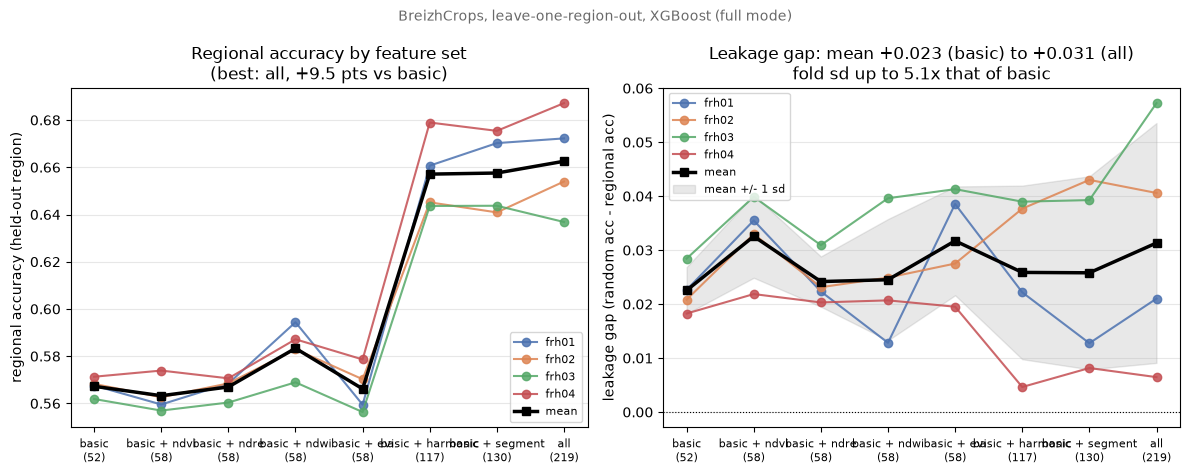

In [13]:
order = list(FEATURE_SETS)
xs = np.arange(len(order))
labels = [f"{s}\n({agg.loc[s, 'n']})" for s in order]
colors = {"frh01": "#4C72B0", "frh02": "#DD8452", "frh03": "#55A868", "frh04": "#C44E52"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, metric in [(ax1, "regional_acc"), (ax2, "gap_acc")]:
    piv = exp2.pivot(index="feature_set", columns="fold", values=metric).reindex(order)[REGIONS]
    for r in REGIONS:
        ax.plot(xs, piv[r].values, marker="o", color=colors[r], lw=1.5, alpha=.85, label=r)
    mean = piv.mean(axis=1).values
    ax.plot(xs, mean, color="black", lw=2.5, marker="s", label="mean")
    ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8); ax.grid(axis="y", alpha=.3)

sd = exp2.pivot(index="feature_set", columns="fold", values="gap_acc").reindex(order).std(axis=1).values
gm = agg.loc[order, "gap_mean"].values
ax2.fill_between(xs, gm - sd, gm + sd, color="grey", alpha=.18, label="mean +/- 1 sd")
ax2.axhline(0, color="black", lw=.8, ls=":")
best = agg.regional_acc.idxmax()
gain = (agg.loc[best, "regional_acc"] - agg.loc["basic", "regional_acc"]) * 100
ax1.set_title(f"Regional accuracy by feature set\n(best: {best}, {gain:+.1f} pts vs basic)")
ax1.set_ylabel("regional accuracy (held-out region)")
ax2.set_title(f"Leakage gap: mean {gm[0]:+.3f} (basic) to {gm[-1]:+.3f} (all)\n"
              f"fold sd up to {agg.gap_sd_vs_basic.max():.1f}x that of basic")
ax2.set_ylabel("leakage gap (random acc - regional acc)")
ax1.legend(fontsize=8, loc="lower right"); ax2.legend(fontsize=8, loc="upper left")
fig.suptitle(f"BreizhCrops, leave-one-region-out, XGBoost ({MODE} mode)", fontsize=10, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "featureset_leakage.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Experiment 3: the final model

All 202 features. The focal $\gamma$ is **selected**, not asserted: for each
outer fold, an *inner* leave-one-region-out over the three training regions
picks $\gamma$ on macro F1. The outer test region is never seen during
selection.

Inner LORO rather than a single validation region, because Experiments 1 and
2 show that fold-to-fold spread is large for exactly these models, so a single
validation region would mean selecting on noise.

$\gamma=0$ is in the grid, which makes this an ablation as well: if
$\gamma=0$ wins, the benefit comes from the class weights $\alpha$, not from
the focusing term.

In [14]:
t0 = time.time()
X = df[FEATURE_NAMES].values
sel_rows, fold_rows = [], []
pred = np.full(len(y), -1); pred_soft = np.full(len(y), -1)

for outer in REGIONS:
    te, tr = np.where(regions == outer)[0], np.where(regions != outer)[0]
    scores = {g: [] for g in CFG["gamma_grid"]}
    for inner in [r for r in REGIONS if r != outer]:
        v = tr[regions[tr] == inner]
        t_all = tr[regions[tr] != inner]
        t_idx = t_all if CFG["select_frac"] >= 1 else train_test_split(
            t_all, train_size=CFG["select_frac"], stratify=y[t_all], random_state=SEED)[0]
        a = class_weights(y[t_idx])
        for g in CFG["gamma_grid"]:
            s = macro_f1(y[v], fit_predict(X[t_idx], y[t_idx], X[v], g, a))
            scores[g].append(s)
            sel_rows.append(dict(outer=outer, inner_val=inner, gamma=g, macro_f1=s))

    tick(f"exp3: fold {outer}, inner gamma selection done "
         f"({len(CFG['gamma_grid']) * 3} fits)")
    best = max(scores, key=lambda g: np.mean(scores[g]))
    pred[te] = fit_predict(X[tr], y[tr], X[te], best, class_weights(y[tr]))
    pred_soft[te] = fit_predict(X[tr], y[tr], X[te])
    fold_rows.append(dict(fold=outer, gamma=best,
                          weighted_acc=accuracy_score(y[te], pred[te]), weighted_f1=macro_f1(y[te], pred[te]),
                          softmax_acc=accuracy_score(y[te], pred_soft[te]), softmax_f1=macro_f1(y[te], pred_soft[te])))
    tick(f"exp3: fold {outer} complete, gamma={best:g}")
    print(f"  {outer}: selected gamma={best:g}   inner means "
          + "  ".join(f"g{g:g}={np.mean(s):.4f}" for g, s in scores.items()))

exp3 = pd.DataFrame(fold_rows)
sel = pd.DataFrame(sel_rows)
exp3.to_csv(RESULTS_DIR / "exp3_final_folds.csv", index=False)
sel.to_csv(RESULTS_DIR / "exp3_gamma_selection.csv", index=False)
pd.DataFrame(dict(region=regions, y_true=y, pred_weighted=pred, pred_softmax=pred_soft)
             ).to_csv(DATA_DIR / "exp3_predictions.csv", index=False)

print("\ninner selection, mean macro F1 by gamma:")
display(sel.pivot_table(index="outer", columns="gamma", values="macro_f1").round(4))
print("final models, fold mean +/- sd:")
display(exp3[["weighted_acc", "softmax_acc", "weighted_f1", "softmax_f1"]].agg(["mean", "std"]).round(4))
print("per fold, weighted minus softmax:")
display(pd.DataFrame(dict(fold=exp3.fold, d_acc=exp3.weighted_acc - exp3.softmax_acc,
                          d_f1=exp3.weighted_f1 - exp3.softmax_f1)).set_index("fold").round(4))
print(f"[{time.time() - t0:.0f}s]")

[18:11:32  + 256.8 min]  exp3: fold frh01, inner gamma selection done (12 fits)


[18:24:33  + 269.8 min]  exp3: fold frh01 complete, gamma=0
  frh01: selected gamma=0   inner means g0=0.5270  g1=0.5252  g2=0.5222  g3=0.5200


[18:52:03  + 297.3 min]  exp3: fold frh02, inner gamma selection done (12 fits)


[19:05:53  + 311.1 min]  exp3: fold frh02 complete, gamma=0
  frh02: selected gamma=0   inner means g0=0.5265  g1=0.5254  g2=0.5249  g3=0.5234


[19:31:51  + 337.1 min]  exp3: fold frh03, inner gamma selection done (12 fits)


...

final models, fold mean +/- sd:


,weighted_acc,softmax_acc,weighted_f1,softmax_f1
mean,0.6569,0.6625,0.5611,0.5306
std,0.0382,0.0219,0.0612,0.0352


per fold, weighted minus softmax:


,d_acc,d_f1
fold,,
frh01,0.0028,0.0521
frh02,0.0326,0.0624
frh03,-0.0357,-0.0109
frh04,-0.0222,0.0184


[9676s]


### Where the errors are

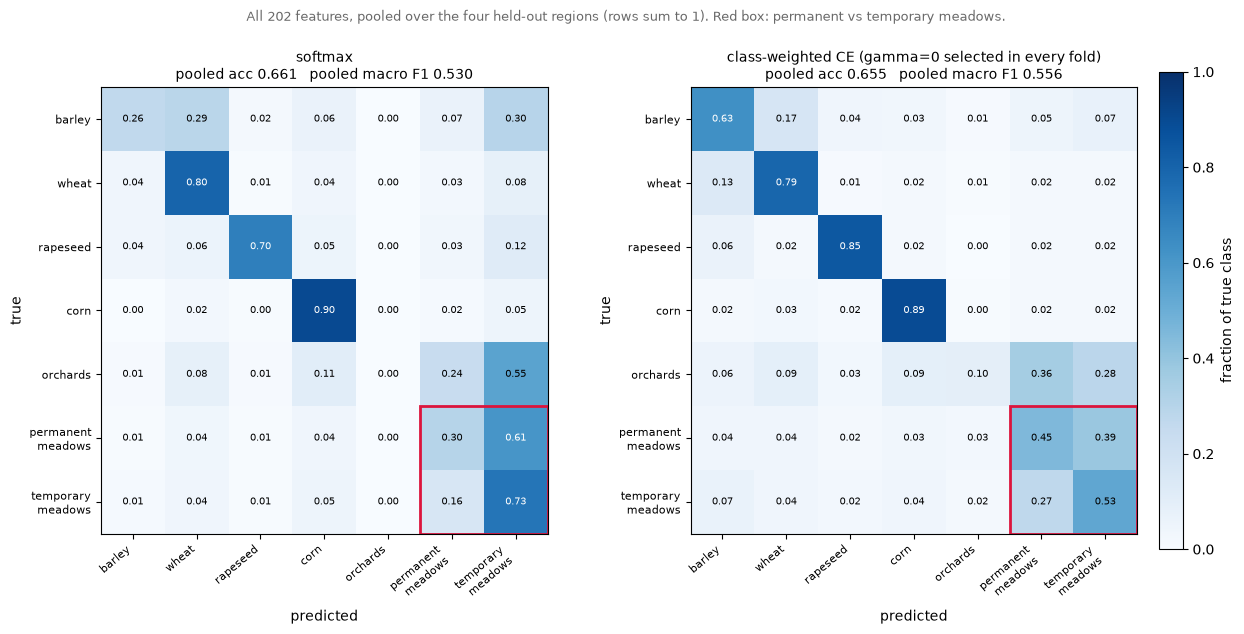

In [15]:
wlabel = ("class-weighted CE (gamma=0 selected in every fold)" if set(exp3.gamma) == {0.0}
          else f"focal (gamma per fold: {', '.join(f'{g:g}' for g in exp3.gamma)})")

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
fig.subplots_adjust(wspace=.32)
short = [c.replace(" ", "\n") for c in CLASS_NAMES]
for ax, (title, yp) in zip(axes, [("softmax", pred_soft), (wlabel, pred)]):
    cm = confusion_matrix(y, yp, labels=range(K))
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(short, rotation=40, ha="right", fontsize=8)
    ax.set_yticklabels(short, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if cmn[i, j] > .55 else "black")
    mi, ti = CLASS_NAMES.index("permanent meadows"), CLASS_NAMES.index("temporary meadows")
    lo = min(mi, ti) - .5
    ax.add_patch(plt.Rectangle((lo, lo), 2, 2, fill=False, edgecolor="crimson", lw=2))
    ax.set_title(f"{title}\npooled acc {accuracy_score(y, yp):.3f}   "
                 f"pooled macro F1 {macro_f1(y, yp):.3f}", fontsize=10)
fig.colorbar(im, ax=axes, fraction=.025, pad=.02, label="fraction of true class")
fig.suptitle("All 202 features, pooled over the four held-out regions (rows sum to 1). "
             "Red box: permanent vs temporary meadows.", fontsize=9, color="dimgrey")
fig.savefig(FIG_DIR / "confusion_final.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
for name, yp in [("softmax", pred_soft), ("weighted", pred)]:
    pr, rc, f1, sup = precision_recall_fscore_support(y, yp, labels=range(K), zero_division=0)
    print(f"--- {name} (pooled) ---")
    display(pd.DataFrame(dict(precision=pr, recall=rc, f1=f1, n_true=sup,
                              n_predicted=np.bincount(yp, minlength=K)), index=CLASS_NAMES).round(3))

mi, ti = CLASS_NAMES.index("permanent meadows"), CLASS_NAMES.index("temporary meadows")
merge = lambda a: np.where(a == ti, mi, a)
print("share of errors that are permanent <-> temporary meadow confusions, and accuracy if merged:")
for name, yp in [("softmax", pred_soft), ("weighted", pred)]:
    cm = confusion_matrix(y, yp, labels=range(K))
    errs = cm.sum() - np.trace(cm)
    print(f"  {name:9s} {(cm[mi, ti] + cm[ti, mi]) / errs:6.1%} of errors   "
          f"accuracy {accuracy_score(y, yp):.4f} -> {accuracy_score(merge(y), merge(yp)):.4f} merged")

oi = CLASS_NAMES.index("orchards")
cm = confusion_matrix(y, pred, labels=range(K))
print(f"\nweighted model: {cm[:, oi].sum()} parcels predicted orchards, {cm[oi, oi]} correct "
      f"(precision {cm[oi, oi] / max(cm[:, oi].sum(), 1):.3f}). False positives by true class:")
print(pd.Series(np.delete(cm[:, oi], oi), index=[c for c in CLASS_NAMES if c != "orchards"]).to_string())

stable = "softmax" if exp3.softmax_acc.std() <= exp3.weighted_acc.std() else "weighted"
print(f"\nacross-region accuracy sd: softmax {exp3.softmax_acc.std():.4f}, "
      f"weighted {exp3.weighted_acc.std():.4f} -> more predictable: {stable}")

--- softmax (pooled) ---


,precision,recall,f1,n_true,n_predicted
barley,0.541,0.264,0.355,36905,17989
wheat,0.722,0.799,0.758,89555,99122
rapeseed,0.717,0.695,0.706,14732,14277
corn,0.867,0.902,0.884,153908,160029
orchards,0.000,0.000,0.000,3070,0
permanent meadows,0.505,0.299,0.376,127813,75747
temporary meadows,0.555,0.734,0.632,182212,241031


--- weighted (pooled) ---


,precision,recall,f1,n_true,n_predicted
barley,0.411,0.630,0.498,36905,56589
wheat,0.747,0.791,0.768,89555,94882
rapeseed,0.513,0.846,0.639,14732,24285
corn,0.899,0.892,0.895,153908,152632
orchards,0.031,0.095,0.047,3070,9403
permanent meadows,0.500,0.449,0.473,127813,114974
temporary meadows,0.625,0.533,0.575,182212,155430


share of errors that are permanent <-> temporary meadow confusions, and accuracy if merged:
  softmax    51.9% of errors   accuracy 0.6613 -> 0.8371 merged


  weighted   47.2% of errors   accuracy 0.6554 -> 0.8181 merged

weighted model: 9403 parcels predicted orchards, 292 correct (precision 0.031). False positives by true class:
barley                321
wheat                 493
rapeseed               56
corn                  744
permanent meadows    3420
temporary meadows    4077

across-region accuracy sd: softmax 0.0219, weighted 0.0382 -> more predictable: softmax


**Why the meadow confusion matters.** Under EU CAP rules, permanent grassland
is land in grass that has not been in the holding's crop rotation for five
years or more; temporary grassland is grass for five years or less
(Regulation (EU) No 1307/2013, Art. 4(1)(h), as amended by Regulation (EU)
2017/2393). The two labels are separated by *multi-year land-use history*.
The model sees one season. Some single-season signal exists, since temporary
grass tends to be managed more intensively and is sometimes resown, but the
defining criterion lies outside the input. The share of errors printed above
therefore measures how much of the remaining error comes from the task
specification rather than from the model.

## 9b. Overfitting check: learning curves

200 rounds at depth 6 on 219 features is enough capacity to memorise, so the
question a reader should ask is whether more boosting rounds are still
helping generalisation or only fitting the training set.

Tracked on one fold: training error, error on a size-matched random test set,
and error on the held-out region, all as a function of boosting round. The
gap between the random and regional curves is the leakage gap appearing
round by round.

[20:33:19  + 398.6 min]  learning curves: training finished


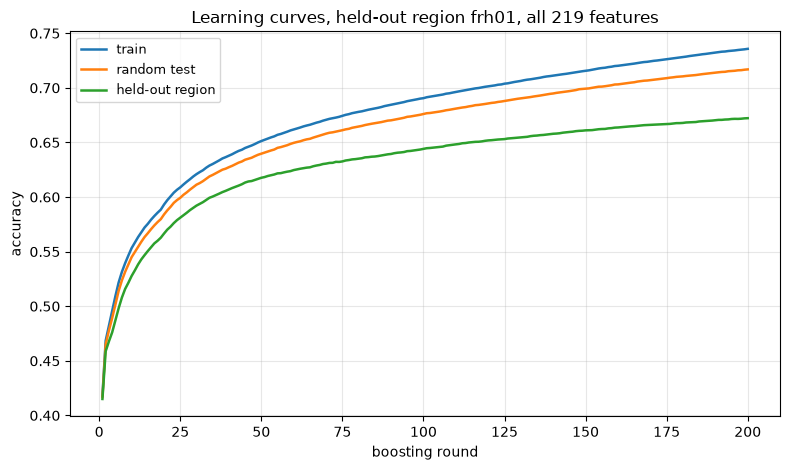

at round 200: train 0.7357   random 0.7169   regional 0.6722
generalisation gap (train - regional): 0.0635
best regional accuracy at round 200 (0.6722); still improving at the end
[382s]


In [17]:
t0 = time.time()
CURVE_FOLD = REGIONS[0]
X = df[FEATURE_NAMES].values
te, tr = regions == CURVE_FOLD, regions != CURVE_FOLD
i_tr, i_te = matched_random_split(int(tr.sum()), int(te.sum()))

dtrain = xgb.DMatrix(X[tr], label=y[tr])          # built once, used for fit and eval
evals_result = {}
bst = xgb.train(
    {"max_depth": MAX_DEPTH, "eta": ETA, "num_class": K, "nthread": -1, "seed": SEED,
     "objective": "multi:softmax", "eval_metric": "merror"},
    dtrain, CFG["rounds"],
    # XGBoost rejects "-" in eval set names, so these are renamed for display below
    evals=[(dtrain, "train"),
           (xgb.DMatrix(X[i_te], label=y[i_te]), "random_test"),
           (xgb.DMatrix(X[te], label=y[te]), "regional_test")],
    evals_result=evals_result, verbose_eval=False)

LABELS = {"train": "train", "random_test": "random test",
          "regional_test": "held-out region"}
curve = pd.DataFrame({LABELS[k]: 1 - np.array(v["merror"])
                      for k, v in evals_result.items()})
curve.index.name = "round"
curve.to_csv(RESULTS_DIR / "learning_curve.csv")

tick("learning curves: training finished")

fig, ax = plt.subplots(figsize=(8, 4.8))
for col, style in [("train", "-"), ("random test", "-"), ("held-out region", "-")]:
    ax.plot(curve.index + 1, curve[col], style, lw=1.8, label=col)
ax.set_xlabel("boosting round"); ax.set_ylabel("accuracy")
ax.set_title(f"Learning curves, held-out region {CURVE_FOLD}, all {len(FEATURE_NAMES)} features")
ax.grid(alpha=.3); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()

last = curve.iloc[-1]
print(f"at round {len(curve)}: train {last['train']:.4f}   "
      f"random {last['random test']:.4f}   regional {last['held-out region']:.4f}")
print(f"generalisation gap (train - regional): {last['train'] - last['held-out region']:.4f}")
best_round = int(curve["held-out region"].idxmax()) + 1
print(f"best regional accuracy at round {best_round} "
      f"({curve['held-out region'].max():.4f}); "
      f"{'still improving at the end' if best_round > 0.9 * len(curve) else 'plateaued or declined after that'}")
print(f"[{time.time() - t0:.0f}s]")

## 10. Experiment 4: which features does the model actually rely on?

**Why not XGBoost's built-in importance.** These features are heavily
correlated: 13 bands x 4 statistics, plus harmonics and segment means of the
same bands. Gain-based importance splits credit arbitrarily between
correlated features, so a band can look unimportant simply because a twin
absorbed the credit. Dropping bands on that basis would be unsound.

**Grouped permutation importance instead.** All features derived from one
band are shuffled *together*, which destroys the twins at the same time, and
the drop in accuracy is measured. That answers "how much does the model rely
on this band", on held-out data rather than on the training set.

**Measured under both splits.** A group that matters much more under the
random split than under the regional one is signal the model leans on but
which does not transfer between regions. That makes this a second, independent
probe of the main finding rather than a side quest.

The models are the ones Experiment 2 already fitted on the full feature set,
so nothing is retrained here.

In [18]:
t0 = time.time()
PERM_TEST_MAX = 30000        # test rows sampled per fold, for speed
PERM_REPEATS = 2

groups = {f"band {i} ({b})": [c for c in FEATURE_NAMES if c.startswith(f"{b}_")]
          for i, b in enumerate(BANDS)}
groups.update({f"index {ix}": FAMILIES[ix] for ix in INDICES})
assert sum(len(v) for v in groups.values()) == len(FEATURE_NAMES), "groups must partition the features"

col_pos = {c: i for i, c in enumerate(STORED[REGIONS[0]]["cols"])}
rng_perm = np.random.default_rng(SEED)
rows = []

for held in REGIONS:
    st = STORED[held]
    Xall = df[st["cols"]].values
    for arm, model, idx in [("regional", st["model_reg"], st["te"]),
                            ("random",   st["model_ran"], st["i_te"])]:
        if len(idx) > PERM_TEST_MAX:
            idx = rng_perm.choice(idx, PERM_TEST_MAX, replace=False)
        Xte, yte = Xall[idx], y[idx]
        base = accuracy_score(yte, predict(model, Xte))
        for gname, gcols in groups.items():
            pos = [col_pos[c] for c in gcols]
            drops = []
            for _ in range(PERM_REPEATS):
                Xp = Xte.copy()
                Xp[:, pos] = Xp[rng_perm.permutation(len(Xp))][:, pos]
                drops.append(base - accuracy_score(yte, predict(model, Xp)))
            rows.append(dict(fold=held, split=arm, group=gname,
                             base_acc=base, drop=float(np.mean(drops))))
    tick(f"exp4: fold {held} done")

exp4 = pd.DataFrame(rows)
exp4.to_csv(RESULTS_DIR / "exp4_permutation_importance.csv", index=False)

imp = (exp4.pivot_table(index="group", columns="split", values="drop", aggfunc="mean")
       .rename(columns={"regional": "drop_regional", "random": "drop_random"}))
imp["difference"] = imp.drop_random - imp.drop_regional
imp = imp.sort_values("drop_regional", ascending=False)
print("accuracy drop when a group is shuffled (mean over 4 folds):")
display(imp.round(4))
print(f"[{time.time() - t0:.0f}s]")

[20:33:44  + 399.0 min]  exp4: fold frh01 done


[20:34:09  + 399.4 min]  exp4: fold frh02 done


[20:34:35  + 399.8 min]  exp4: fold frh03 done


[20:35:00  + 400.3 min]  exp4: fold frh04 done
accuracy drop when a group is shuffled (mean over 4 folds):


split,drop_random,drop_regional,difference
group,,,
band 2 (b2),0.1997,0.1805,0.0192
band 12 (b12),0.1378,0.1195,0.0183
band 9 (b9),0.1120,0.1066,0.0054
band 6 (b6),0.0839,0.0798,0.0041
band 11 (b11),0.0752,0.0656,0.0096
index ndwi,0.0722,0.0632,0.0090
band 10 (b10),0.0489,0.0499,-0.0011
band 5 (b5),0.0333,0.0311,0.0022
band 0 (b0),0.0291,0.0272,0.0019


[101s]


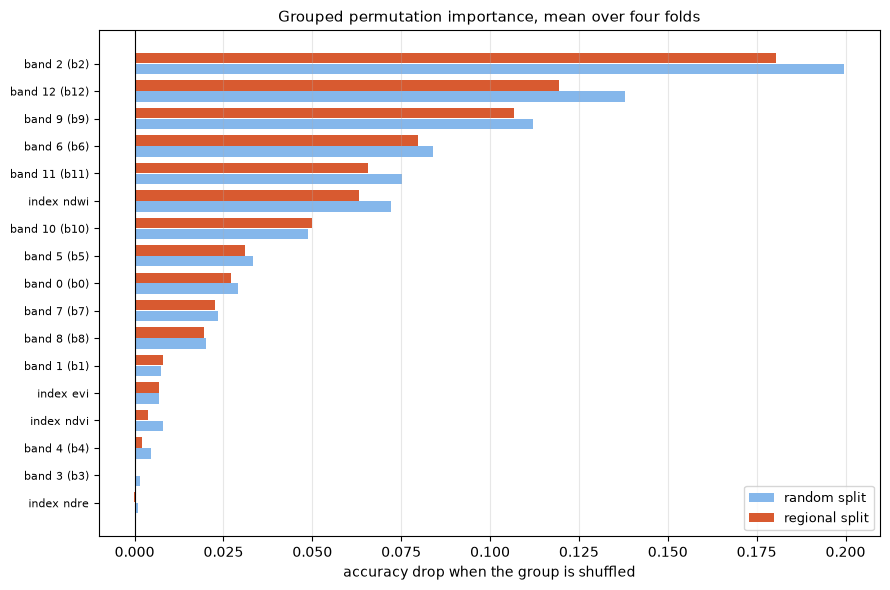

groups the model barely uses (regional drop under 0.002): ['band 3 (b3)', 'index ndre']

Note: low permutation importance shows the model does not rely on a group
given everything else present. It does not prove the group is redundant -
that needs a retrain without it.


In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
o = imp.sort_values("drop_regional")
ys = np.arange(len(o))
ax.barh(ys - 0.2, o.drop_random, height=.38, label="random split", color="#85B7EB")
ax.barh(ys + 0.2, o.drop_regional, height=.38, label="regional split", color="#D85A30")
ax.set_yticks(ys); ax.set_yticklabels(o.index, fontsize=8)
ax.set_xlabel("accuracy drop when the group is shuffled")
ax.set_title("Grouped permutation importance, mean over four folds", fontsize=11)
ax.axvline(0, color="black", lw=.8)
ax.grid(axis="x", alpha=.3); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "permutation_importance.png", dpi=200, bbox_inches="tight")
plt.show()

near_zero = imp[imp.drop_regional.abs() < 0.002].index.tolist()
print(f"groups the model barely uses (regional drop under 0.002): "
      f"{near_zero if near_zero else 'none'}")
print("\nNote: low permutation importance shows the model does not rely on a group")
print("given everything else present. It does not prove the group is redundant -")
print("that needs a retrain without it.")

## 11. Consolidated results

Everything the report needs, in one place.

In [20]:
lines = []
A = lines.append

A("=" * 74)
A(f"HEADLINE RESULTS   ({MODE} mode, {len(df):,} parcels, {K} classes, "
  f"{len(FEATURE_NAMES)} features)")
A("=" * 74)

b = exp1.baseline_acc.mean()
A(f"\nMajority-class baseline          {b:.4f}")

e1 = exp1[exp1.objective == "softmax"]
A(f"\n1. LEAKAGE GAP (basic features, softmax, LORO over 4 regions)")
A(f"   random split      accuracy {e1.random_acc.mean():.4f} +/- {e1.random_acc.std():.4f}")
A(f"   held-out region   accuracy {e1.regional_acc.mean():.4f} +/- {e1.regional_acc.std():.4f}")
A(f"   gap                        {e1.gap_acc.mean():+.4f} +/- {e1.gap_acc.std():.4f}"
  f"   ({int((e1.gap_acc > 0).sum())}/4 folds positive)")
A(f"   train accuracy             {e1.train_acc.mean():.4f}"
  f"   (generalisation gap {e1.generalisation_gap.mean():+.4f})")

A(f"\n2. VARIANCE OF TRANSFER (fold-to-fold sd of accuracy)")
A(f"   random split  sd {e1.random_acc.std():.4f}")
A(f"   regional      sd {e1.regional_acc.std():.4f}"
  f"   ({e1.regional_acc.std() / max(e1.random_acc.std(), 1e-9):.1f}x)")
for s_ in ["basic", "all"]:
    sd = exp2[exp2.feature_set == s_].gap_acc.std()
    A(f"   gap sd, {s_:6s} features {sd:.4f}")

A(f"\n3. FEATURE SETS (softmax, LORO)")
for s_ in FEATURE_SETS:
    r = exp2[exp2.feature_set == s_]
    A(f"   {s_:18s} n={int(r.n_features.iloc[0]):3d}  regional {r.regional_acc.mean():.4f}"
      f"   gap {r.gap_acc.mean():+.4f} +/- {r.gap_acc.std():.4f}")

A(f"\n4. DOES THE FEATURE SET WIDEN THE GAP? (paired vs basic, 4 folds)")
basev = exp2[exp2.feature_set == "basic"].set_index("fold").loc[REGIONS, "gap_acc"]
for s_ in list(FEATURE_SETS)[1:]:
    cur = exp2[exp2.feature_set == s_].set_index("fold").loc[REGIONS, "gap_acc"]
    d, t, p, pos = paired(cur, basev)
    A(f"   {s_:18s} d={d:+.4f}  p={p:.4f}  {pos}/4 folds"
      f"{'  *' if p < 0.05 else ''}")

A(f"\n5. FINAL MODEL (all features, nested LORO)")
A(f"   gamma selected: {', '.join(f'{g:g}' for g in exp3.gamma)}")
A(f"   softmax        accuracy {exp3.softmax_acc.mean():.4f} +/- {exp3.softmax_acc.std():.4f}"
  f"   macro F1 {exp3.softmax_f1.mean():.4f} +/- {exp3.softmax_f1.std():.4f}")
A(f"   weighted CE    accuracy {exp3.weighted_acc.mean():.4f} +/- {exp3.weighted_acc.std():.4f}"
  f"   macro F1 {exp3.weighted_f1.mean():.4f} +/- {exp3.weighted_f1.std():.4f}")

cm_s = confusion_matrix(y, pred_soft, labels=range(K))
errs = cm_s.sum() - np.trace(cm_s)
A(f"\n6. WHERE THE ERROR LIVES (softmax, pooled)")
A(f"   permanent <-> temporary meadow = {(cm_s[mi, ti] + cm_s[ti, mi]) / errs:.1%} of all errors")
A(f"   accuracy {accuracy_score(y, pred_soft):.4f} -> "
  f"{accuracy_score(merge(y), merge(pred_soft)):.4f} if those two classes are merged")

A(f"\n7. TOP FEATURE GROUPS (permutation, regional split)")
for g, r in imp.head(5).iterrows():
    A(f"   {g:22s} drop {r.drop_regional:+.4f} (regional)  {r.drop_random:+.4f} (random)")

A("\n" + "=" * 74)
out = "\n".join(lines)
print(out)
(RESULTS_DIR / "headline_results.txt").write_text(out, encoding="utf-8")
print(f"\nwritten to {RESULTS_DIR / 'headline_results.txt'}")

HEADLINE RESULTS   (full mode, 608,195 parcels, 7 classes, 219 features)

Majority-class baseline          0.2998

1. LEAKAGE GAP (basic features, softmax, LORO over 4 regions)
   random split      accuracy 0.5898 +/- 0.0006
   held-out region   accuracy 0.5673 +/- 0.0039
   gap                        +0.0225 +/- 0.0043   (4/4 folds positive)
   train accuracy             0.6300   (generalisation gap +0.0627)

2. VARIANCE OF TRANSFER (fold-to-fold sd of accuracy)
   random split  sd 0.0006
   regional      sd 0.0039   (6.9x)
   gap sd, basic  features 0.0043
   gap sd, all    features 0.0222

3. FEATURE SETS (softmax, LORO)
   basic              n= 52  regional 0.5673   gap +0.0225 +/- 0.0043
   basic + ndvi       n= 58  regional 0.5633   gap +0.0326 +/- 0.0077
   basic + ndre       n= 58  regional 0.5670   gap +0.0242 +/- 0.0047
   basic + ndwi       n= 58  regional 0.5833   gap +0.0245 +/- 0.0112
   basic + evi        n= 58  regional 0.5662   gap +0.0317 +/- 0.0101
   basic + harmoni

## 12. Summary

*Written after the full run, from the outputs above.*

In [21]:
tick("ALL DONE")
print(f"total runtime {(time.time() - T_START) / 60:.1f} min   (mode: {MODE})")

[20:35:01  + 400.3 min]  ALL DONE
total runtime 400.3 min   (mode: full)
